# Deep Contextual Denoising Autoencoder - Learning an Arbitrary Association
This notebook trains a contextual denoising autoencoder on the MNIST dataset to simulate a neuroscience experiment that investigates the formation of a multisensory association. The goal is to explore how adding a "contextual" input (representing an additional sensory modality) consistently paired with specific visual categories can bias neural representations and behavior. In this setup, the model reconstructs images from noisy inputs and integrates contextual information to capture the association, providing a framework to generate predictions for the real experiment. This version of the notebook is called "deep" because we added an extra fully connected layer between the context and the latent representation.

In [39]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE
from scipy.spatial.distance import pdist, squareform
import torch
import os
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torchvision
from torchvision.utils import save_image
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from src.models import *
from src.utils import *
import os

In [2]:
# to prevent crash due to MKL
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# check if cuda is available
cuda_enabled = torch.cuda.is_available()
# print result
print("CUDA is enabled:", cuda_enabled)
# additional information if CUDA is enabled
if cuda_enabled:
    print("CUDA device count:", torch.cuda.device_count())
    print("CUDA current device:", torch.cuda.current_device())
    print("CUDA device name:", torch.cuda.get_device_name(torch.cuda.current_device()))
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
# set dark background for plots
plt.style.use('dark_background')

CUDA is enabled: True
CUDA device count: 1
CUDA current device: 0
CUDA device name: NVIDIA RTX 2000 Ada Generation Laptop GPU


### MNIST Data Loading
MNIST images show digits from 0-9 in 28x28 grayscale images. We normalize and center them around 0, which gives a slight performance boost during training. We create both a training set and a test set. This time we will also add noise to the images to be reconstructed during training.

In [3]:
# set batch size
batch_size = 128
# define preprocessing image transformation for MNIST dataset
img_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
# load MNIST dataset, training set
train_dataset = MNIST(root='./data/MNIST', download=True, train=True, transform=img_transform)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# load MNIST dataset, testing set
test_dataset = MNIST(root='./data/MNIST', download=True, train=False, transform=img_transform)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

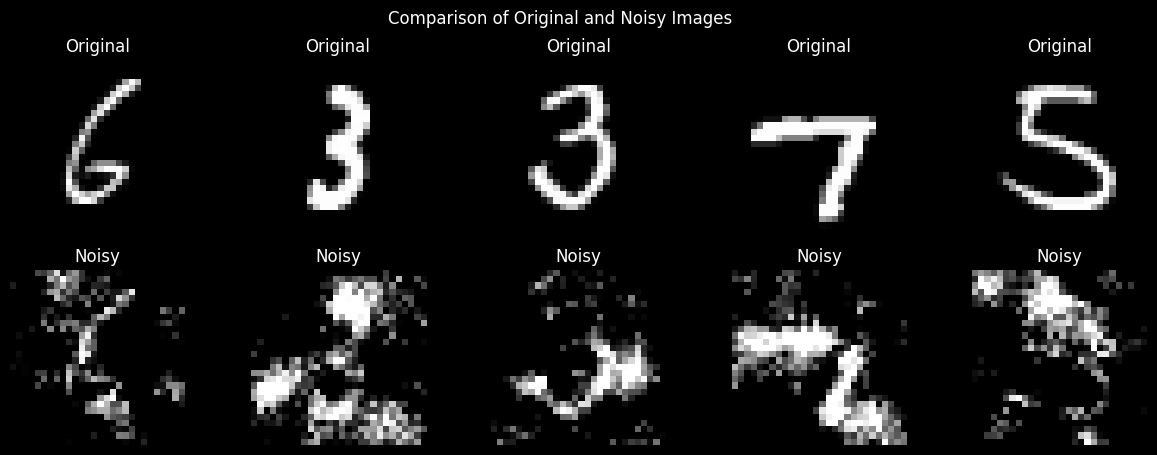

Images batch shape: torch.Size([128, 1, 28, 28])


In [4]:
# set noise level for the context and training data
training_noise_level = 0.5  # noise level of the training data

# select a batch of images from the training data
images, _ = next(iter(train_dataloader))

# generate noisy images using the `add_noise` function with both correlated and uncorrelated noise
noisy_images = add_noise(
    images, 
    noise_level=training_noise_level, 
    correlated=True,  # set to True to apply correlated noise
    uncorrelated=True,  # set to True to apply uncorrelated noise
    kernel_size=11,  # kernel size for the Gaussian filter
    sigma=2.0  # standard deviation of the Gaussian filter
)

# visualize the images to inspect the level of noise corruption that will be used for training
visualize_noisy_images(images, noisy_images, num_images=5)

# print the shape of the images tensor
print("Images batch shape:", images.shape)


In [5]:
# Hyperparameters
learning_rate = 0.001
num_epochs_baseline = 50
num_epochs_association = 100
context_dim = 10  # adjustable context dimensionality
capacity = 16  # model capacity
latent_dims = 32  # latent space dimensionality
target_digit = 3  # digit associated with high-value whisker context
context_signal_level = 1.00  # signal level of the context
context_noise_level = 0.10  # noise level of the context
context_id = 2  # context position in the context vector

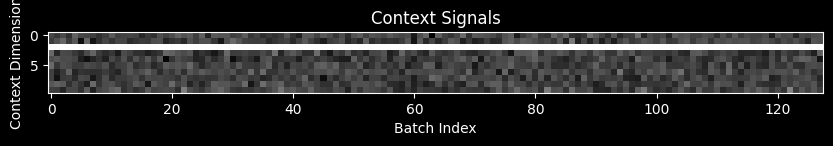

Context batch shape: torch.Size([128, 10])


In [6]:
# generate a batch of context signals
context_batch = generate_context(noisy_images.size(0),
                                 signal_level=context_signal_level,
                                 noise_level=context_noise_level,
                                 category_id=context_id,
                                 context_dim=context_dim,
                                 device=device)

# visualize the context signals as a heatmap
plt.figure(figsize=(10, 5))
plt.imshow(context_batch.T.cpu(), cmap='gray', interpolation='nearest')
plt.title("Context Signals")
plt.ylabel("Context Dimension")
plt.xlabel("Batch Index")
plt.show()

# print the shape of the context tensor
print("Context batch shape:", context_batch.shape)

Baseline Training Phase (Denoising Autoencoder)
Epoch 1/50, Baseline Loss: 0.23942497255070122
Epoch 2/50, Baseline Loss: 0.12494850401748726
Epoch 3/50, Baseline Loss: 0.1094141070808429
Epoch 4/50, Baseline Loss: 0.10162384931975083
Epoch 5/50, Baseline Loss: 0.09700571197563651
Epoch 6/50, Baseline Loss: 0.0937751291561991
Epoch 7/50, Baseline Loss: 0.09143686516961055
Epoch 8/50, Baseline Loss: 0.08954666777333217
Epoch 9/50, Baseline Loss: 0.08807320638633231
Epoch 10/50, Baseline Loss: 0.08692327427711569
Epoch 11/50, Baseline Loss: 0.08566331828453902
Epoch 12/50, Baseline Loss: 0.08492198357704098
Epoch 13/50, Baseline Loss: 0.0838873056269912
Epoch 14/50, Baseline Loss: 0.0832905069088885
Epoch 15/50, Baseline Loss: 0.08251475005833579
Epoch 16/50, Baseline Loss: 0.08208394339725153
Epoch 17/50, Baseline Loss: 0.08160986759261027
Epoch 18/50, Baseline Loss: 0.0808471927860144
Epoch 19/50, Baseline Loss: 0.08063831486935809
Epoch 20/50, Baseline Loss: 0.08028029833139895
Epoch 

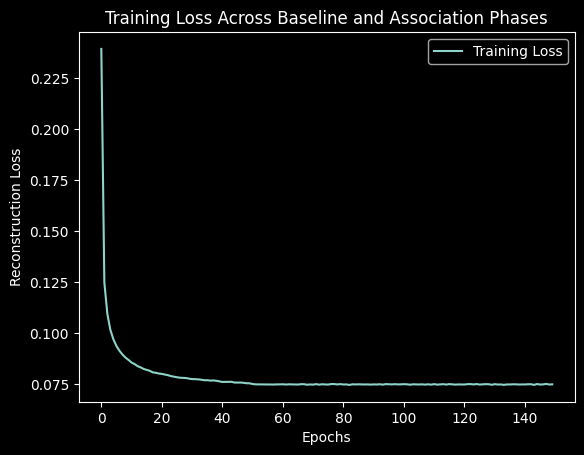

In [7]:
# set retrain flag and define file paths for both models
retrain = False
pretrained_dir = './pretrained'
baseline_model_path = os.path.join(pretrained_dir, 'baseline_deep_autoencoder.pth')
association_model_path = os.path.join(pretrained_dir, 'association_deep_autoencoder.pth')
if not os.path.isdir(pretrained_dir):
    os.makedirs(pretrained_dir)

# instantiate model and define optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
autoencoder = Autoencoder(capacity, latent_dims, context_dim).to(device)

# load models if they exist and retrain is set to False
baseline_trained = os.path.isfile(baseline_model_path)
association_trained = os.path.isfile(association_model_path)

if not retrain and baseline_trained and association_trained:

    # load both models
    baseline_autoencoder = Autoencoder(capacity, latent_dims, context_dim).to(device)
    association_autoencoder = Autoencoder(capacity, latent_dims, context_dim).to(device)
    baseline_autoencoder.load_state_dict(torch.load(baseline_model_path))
    association_autoencoder.load_state_dict(torch.load(association_model_path))
    print("Loaded pretrained baseline and association models.")

else:

    # initialize the optimizer
    optimizer = torch.optim.Adam(autoencoder.parameters(), lr=learning_rate)
    # initialize the training loss list
    train_loss_avg = []

    # baseline training phase
    print("Baseline Training Phase (Denoising Autoencoder)")
    for epoch in range(num_epochs_baseline):
        total_loss = 0
        for image_batch, _ in train_dataloader:
            image_batch = image_batch.to(device)

            # generate context for the batch (default)
            context_batch = generate_context(image_batch.size(0),
                                                   signal_level=None,
                                                   noise_level=context_noise_level,
                                                   category_id=context_id,
                                                   context_dim=context_dim,
                                                   device=device)
            # apply noise to inputs
            noisy_image_batch = add_noise(image_batch, 
                                        noise_level=training_noise_level, 
                                        correlated=True,  # set to True to apply correlated noise
                                        uncorrelated=True,  # set to True to apply uncorrelated noise
                                        kernel_size=11,  # kernel size for the Gaussian filter
                                        sigma=2.0  # standard deviation of the Gaussian filter
                                        )

            # forward pass with noisy input
            reconstructed = autoencoder(noisy_image_batch, context_batch)
            loss = F.mse_loss(reconstructed, image_batch)  

            # backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # calculate the average loss
        avg_loss = total_loss / len(train_dataloader)
        train_loss_avg.append(avg_loss)
        print(f"Epoch {epoch + 1}/{num_epochs_baseline}, Baseline Loss: {avg_loss}")

    # save the baseline model
    torch.save(autoencoder.state_dict(), baseline_model_path)
    print(f"Baseline model saved to {baseline_model_path}")

    # copy the baseline model state to a separate variable for later analysis
    baseline_autoencoder = Autoencoder(capacity, latent_dims, context_dim).to(device)
    baseline_autoencoder.load_state_dict(torch.load(baseline_model_path))

    # freeze all parts of the network except the context layer before association training
    freeze_except_context(autoencoder)

    # update the optimizer to only include the trainable parameters (i.e., the context layer)
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, autoencoder.parameters()), lr=learning_rate)

    # association training phase
    print("\nAssociation Training Phase (Denoising Autoencoder with Enhanced Context - Frozen Weights)")
    for epoch in range(num_epochs_association):
        total_loss = 0
        for image_batch, label_batch in train_dataloader:
            image_batch = image_batch.to(device)
            label_batch = label_batch.to(device)
            
            # generate context for the batch (default)
            context_batch = generate_context(image_batch.size(0),
                                                   signal_level=None,
                                                   noise_level=context_noise_level,
                                                   category_id=context_id,
                                                   context_dim=context_dim,
                                                   device=device)
            # generate context for the batch (associative context)
            target_indices = (label_batch == target_digit).nonzero(as_tuple=True)[0]
            if len(target_indices) > 0:
                context_batch[target_indices] = generate_context(len(target_indices),
                                                   signal_level=context_signal_level,
                                                   noise_level=context_noise_level,
                                                   category_id=context_id,
                                                   context_dim=context_dim,
                                                   device=device)

            # apply noise to inputs
            noisy_image_batch = add_noise(image_batch, 
                                        noise_level=training_noise_level, 
                                        correlated=True,  # set to True to apply correlated noise
                                        uncorrelated=True,  # set to True to apply uncorrelated noise
                                        kernel_size=11,  # kernel size for the Gaussian filter
                                        sigma=2.0  # standard deviation of the Gaussian filter
                                        )

            # forward pass with noisy input
            reconstructed = autoencoder(noisy_image_batch, context_batch)
            loss = F.mse_loss(reconstructed, image_batch)

            # backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        # calculate the average loss
        avg_loss = total_loss / len(train_dataloader)
        train_loss_avg.append(avg_loss)
        print(f"Epoch {epoch + 1}/{num_epochs_association}, Association Loss: {avg_loss}")

    # save the association model
    torch.save(autoencoder.state_dict(), association_model_path)
    print(f"Association model saved to {association_model_path}")

    # copy the association model state to a separate variable for later analysis
    association_autoencoder = Autoencoder(capacity, latent_dims, context_dim).to(device)
    association_autoencoder.load_state_dict(torch.load(association_model_path))

    # plot the training curve across both phases
    plt.plot(range(num_epochs_baseline + num_epochs_association), train_loss_avg, label="Training Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Reconstruction Loss")
    plt.legend()
    plt.title("Training Loss Across Baseline and Association Phases")
    plt.show()

Original Images


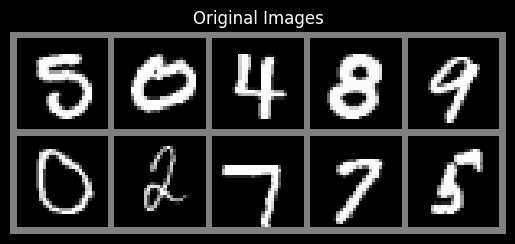

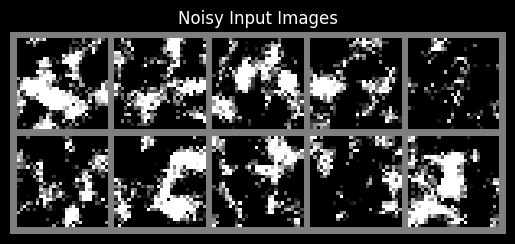

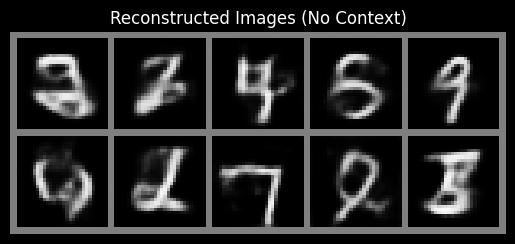

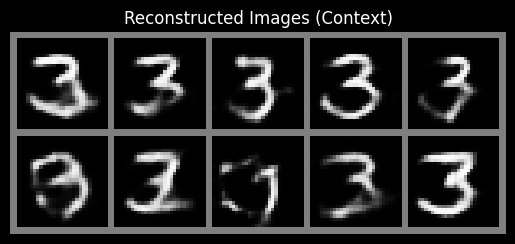

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


In [26]:
# ensure inline plotting for Jupyter notebooks
%matplotlib inline

# ensure the model is in evaluation mode
association_autoencoder.eval()

# display image grid
def show_image(img, title=""):
    img = img.cpu()
    img = 0.5 * (img + 1)
    img = img.clamp(0, 1)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)), cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

# set the context signal level for the test set
test_context_signal_level = 10.0  # signal level of the context

# load a batch of images from the test set and move to the correct device
images_test, labels_test = next(iter(test_dataloader))
images_test = images_test.to(device)

# generate noisy images using the `add_noise` function
noisy_images_test = add_noise(images_test, noise_level=1.0,
                              correlated=True, uncorrelated=True,
                              kernel_size=11, sigma=2.0)

# generate context vectors
context_test = generate_context(noisy_images_test.size(0), signal_level=test_context_signal_level,
                                noise_level=context_noise_level, category_id=context_id,
                                context_dim=10, device=device)
no_context_test = generate_context(noisy_images_test.size(0), signal_level=None,
                                   noise_level=context_noise_level, category_id=context_id,
                                   context_dim=10, device=device)

# get the reconstructed images
reconstructed_images_context = association_autoencoder(noisy_images_test, context_test).cpu()
reconstructed_images_no_context = association_autoencoder(noisy_images_test, no_context_test).cpu()

# display the original, noisy, and reconstructed images
print("Original Images")
show_image(torchvision.utils.make_grid(images_test[:10], nrow=5), title="Original Images")
show_image(torchvision.utils.make_grid(noisy_images_test[:10].cpu(), nrow=5), title="Noisy Input Images")
show_image(torchvision.utils.make_grid(reconstructed_images_no_context[:10], nrow=5), title="Reconstructed Images (No Context)")
show_image(torchvision.utils.make_grid(reconstructed_images_context[:10], nrow=5), title="Reconstructed Images (Context)")

# ensure the output directory exists
output_dir = "./output"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# function to save images at higher resolution
def save_high_res_image(tensor, filename, nrow=5, figsize=(15, 15)):
    grid_img = torchvision.utils.make_grid(tensor, nrow=nrow, padding=2, scale_each=True)
    plt.figure(figsize=figsize)  # Set figure size for higher resolution
    plt.imshow(grid_img.permute(1, 2, 0).cpu().numpy())  # Convert to (H, W, C) format and move to CPU
    plt.axis('off')
    plt.savefig(filename, bbox_inches='tight', dpi=300)  # Save with higher DPI for better resolution
    plt.close()

# save the images
save_high_res_image(images_test[:10], os.path.join(output_dir, "original_images.png"))
save_high_res_image(noisy_images_test[:10].cpu(), os.path.join(output_dir, "noisy_images.png"))
save_high_res_image(reconstructed_images_no_context[:10], os.path.join(output_dir, "reconstructed_images_no_context.png"))
save_high_res_image(reconstructed_images_context[:10], os.path.join(output_dir, "reconstructed_images_context.png"))

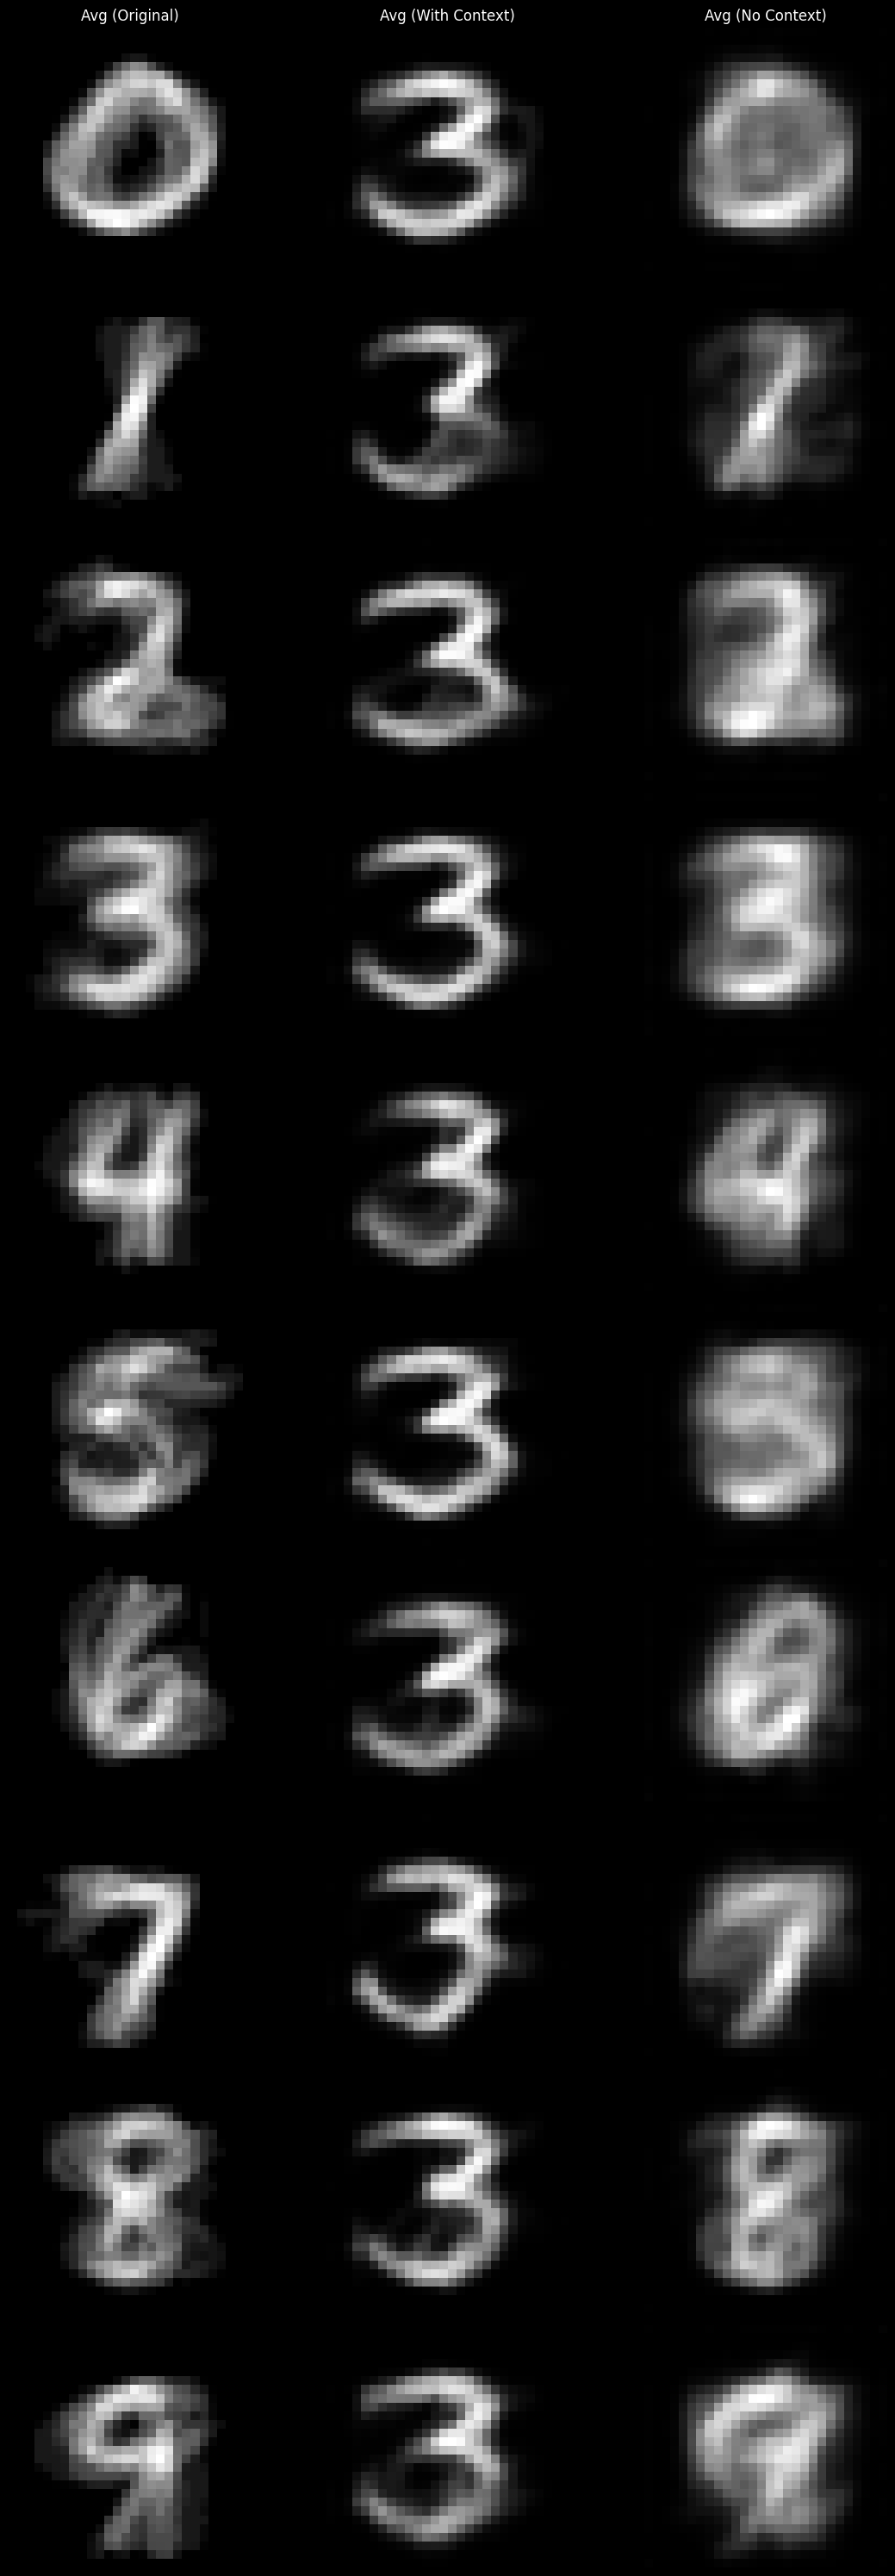

In [42]:
# ensure inline plotting for Jupyter notebooks
%matplotlib inline

# ensure the model is in evaluation mode
association_autoencoder.eval()

# load a batch of images from the test set and move to the correct device
images_test, labels_test = next(iter(test_dataloader))
images_test = images_test.to(device)

# generate noisy images using the `add_noise` function
noisy_images_test = add_noise(images_test, noise_level=1.0, correlated=True, uncorrelated=True, kernel_size=11, sigma=2.0)

# generate context vectors
context_test = generate_context(noisy_images_test.size(0), signal_level=test_context_signal_level, noise_level=context_noise_level, category_id=context_id, context_dim=10, device=device)
no_context_test = generate_context(noisy_images_test.size(0), signal_level=None, noise_level=context_noise_level, category_id=context_id, context_dim=10, device=device)

# get the reconstructed images
reconstructed_images_context = association_autoencoder(noisy_images_test, context_test).cpu()
reconstructed_images_no_context = association_autoencoder(noisy_images_test, no_context_test).cpu()

# function to calculate and visualize average images per category
def plot_average_images(images, labels, reconstructions_with_context, reconstructions_no_context):
    fig, axes_avg = plt.subplots(10, 3, figsize=(12, 30))

    for i in range(10):  # iterate over digit categories
        indices = np.where(labels.cpu().numpy() == i)[0]

        if len(indices) > 0:  # ensure we have samples for this digit
            avg_original = images[indices].mean(dim=0).detach().cpu().numpy()
            avg_with_context = reconstructions_with_context[indices].mean(dim=0).detach().cpu().numpy()
            avg_no_context = reconstructions_no_context[indices].mean(dim=0).detach().cpu().numpy()

            # plot average original image
            axes_avg[i, 0].imshow(avg_original.reshape(28, 28), cmap='gray')
            axes_avg[i, 0].axis('off')
            if i == 0:
                axes_avg[i, 0].set_title('Avg (Original)')

            # plot average image with context
            axes_avg[i, 1].imshow(avg_with_context.reshape(28, 28), cmap='gray')
            axes_avg[i, 1].axis('off')
            if i == 0:
                axes_avg[i, 1].set_title('Avg (With Context)')

            # plot average image without context
            axes_avg[i, 2].imshow(avg_no_context.reshape(28, 28), cmap='gray')
            axes_avg[i, 2].axis('off')
            if i == 0:
                axes_avg[i, 2].set_title('Avg (No Context)')

            axes_avg[i, 0].set_ylabel(f'Digit {i}', fontsize=12)

    plt.tight_layout()
    plt.show()

# visualize average reconstructions for each category
plot_average_images(images_test, labels_test, reconstructed_images_context, reconstructed_images_no_context)


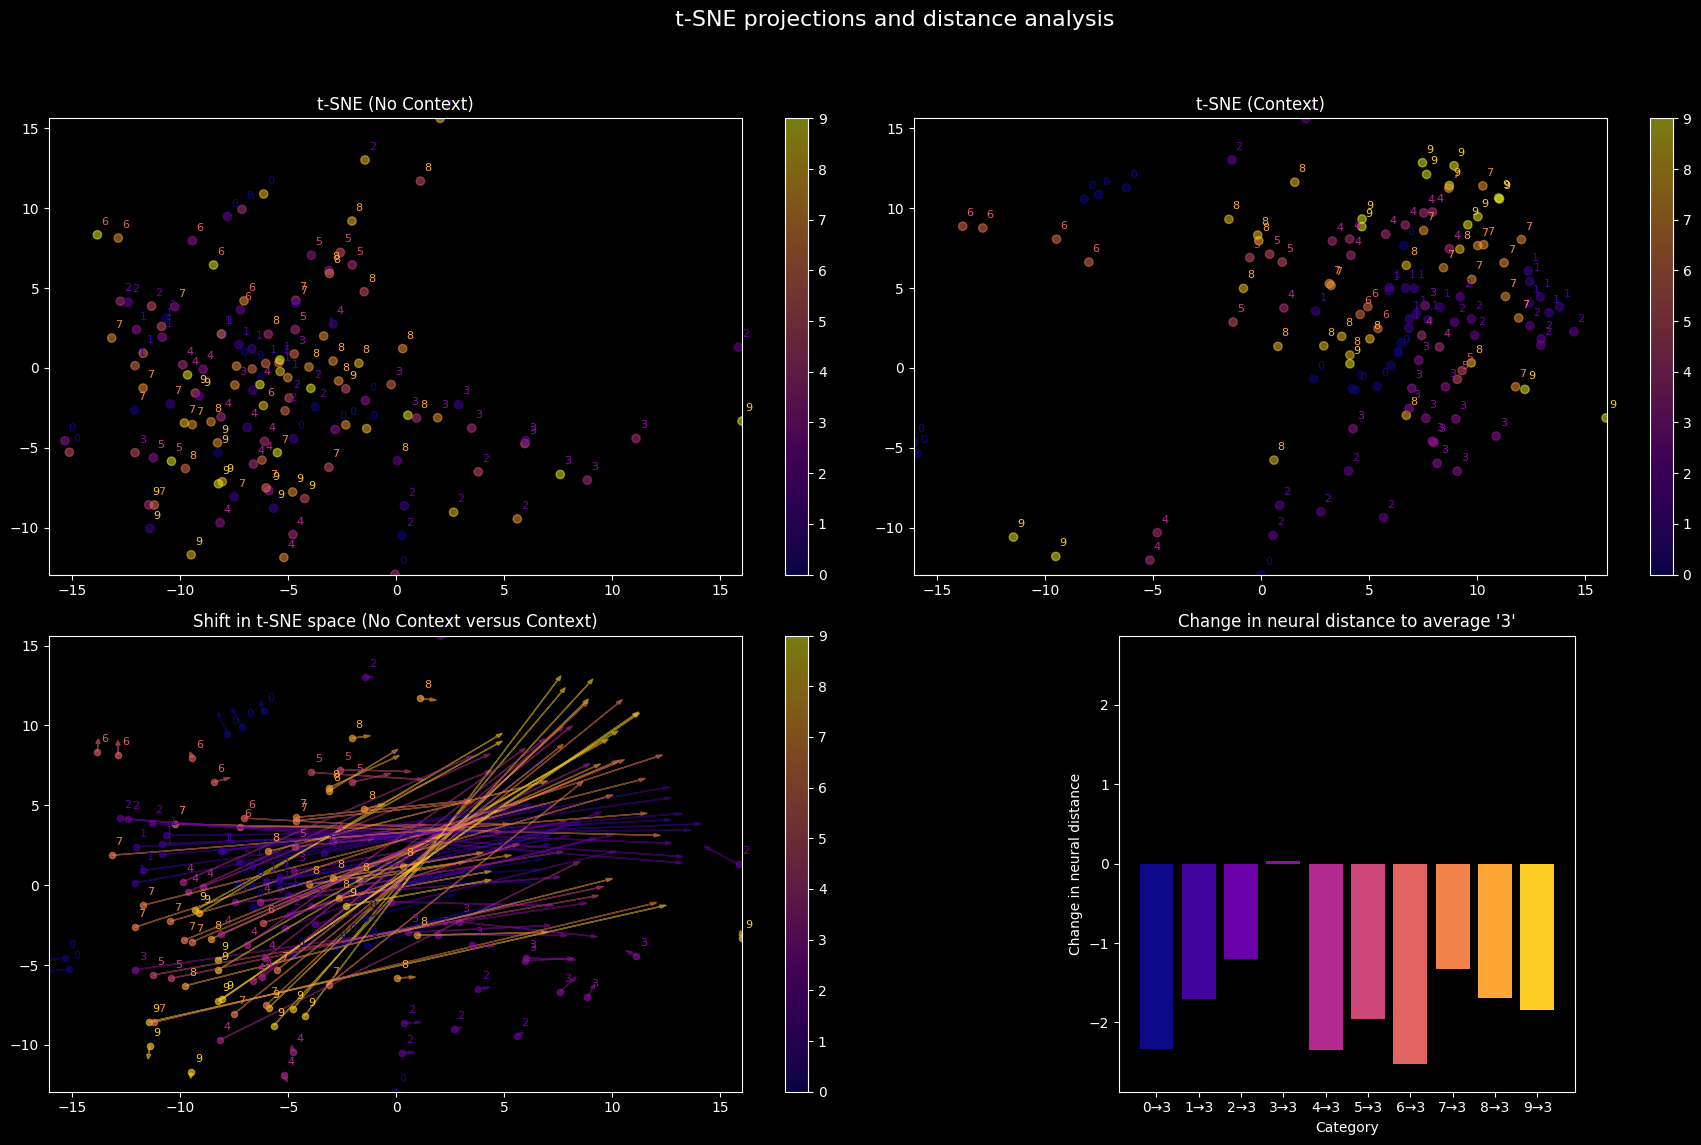

In [62]:
# capture activations from the autoencoder
def capture_activations(model, images, context):
    with torch.no_grad():
        latent = model.encoder(images, context)
        return latent.detach().cpu().numpy()

# ensure the model is in evaluation mode
association_autoencoder.eval()

# load a batch of images from the test set and move to the correct device
images_test, labels_test = next(iter(test_dataloader))
images_test = images_test.to(device)
labels_test = labels_test.cpu().numpy()

# generate noisy images
noisy_images_test = add_noise(images_test, noise_level=training_noise_level, correlated=True, uncorrelated=True, kernel_size=11, sigma=2.0)

# generate context vectors
context_test = generate_context(noisy_images_test.size(0), signal_level=test_context_signal_level, noise_level=context_noise_level, category_id=context_id, context_dim=10, device=device)
no_context_test = generate_context(noisy_images_test.size(0), signal_level=None, noise_level=context_noise_level, category_id=context_id, context_dim=10, device=device)

# capture activations
activations_no_context = capture_activations(association_autoencoder, noisy_images_test, no_context_test)
activations_context = capture_activations(association_autoencoder, noisy_images_test, context_test)

# average activation for "3" with and without context
avg_activation_3_no_context = activations_no_context[labels_test == 3].mean(axis=0)
avg_activation_3_context = activations_context[labels_test == 3].mean(axis=0)
avg_activation_3_avg = (avg_activation_3_no_context + avg_activation_3_context) / 2

# compute change in distance from "3" average activation
distance_diffs = [
    np.linalg.norm(activations_context[labels_test == i] - avg_activation_3_avg, axis=1).mean() -
    np.linalg.norm(activations_no_context[labels_test == i] - avg_activation_3_avg, axis=1).mean()
    for i in range(10)
]

# perform t-SNE on combined activations
combined_activations = np.concatenate([activations_no_context, activations_context], axis=0)
combined_labels = np.concatenate([labels_test, labels_test + 10]) 
tsne = TSNE(n_components=2, random_state=0)
combined_tsne = tsne.fit_transform(combined_activations)

# split the t-SNE results
latent_no_context_tsne = combined_tsne[:len(activations_no_context)]
latent_context_tsne = combined_tsne[len(activations_no_context):]

# set axis limits for synchronization
x_min, x_max = combined_tsne[:, 0].min(), combined_tsne[:, 0].max()
y_min, y_max = combined_tsne[:, 1].min(), combined_tsne[:, 1].max()

# plotting
fig, axs = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("t-SNE projections and distance analysis", fontsize=16)

# t-SNE without context
axs[0, 0].set_title("t-SNE (No Context)")
scatter = axs[0, 0].scatter(latent_no_context_tsne[:, 0], latent_no_context_tsne[:, 1], c=labels, cmap='plasma', alpha=0.5)
axs[0, 0].figure.colorbar(scatter, ax=axs[0, 0], ticks=range(10))
for i, (x, y) in enumerate(latent_no_context_tsne):
    axs[0, 0].text(x + 0.5, y + 0.5, str(labels_test[i]), fontsize=8, ha='right', va='bottom', color=plt.cm.plasma(labels_test[i] / 10))
axs[0, 0].set_xlim(x_min, x_max)
axs[0, 0].set_ylim(y_min, y_max)

# t-SNE with context
axs[0, 1].set_title("t-SNE (Context)")
scatter = axs[0, 1].scatter(latent_context_tsne[:, 0], latent_context_tsne[:, 1], c=labels_test, cmap='plasma', alpha=0.5)
axs[0, 1].figure.colorbar(scatter, ax=axs[0, 1], ticks=range(10))
for i, (x, y) in enumerate(latent_context_tsne):
    axs[0, 1].text(x + 0.5, y + 0.5, str(labels_test[i]), fontsize=8, ha='right', va='bottom', color=plt.cm.plasma(labels_test[i] / 10))
axs[0, 1].set_xlim(x_min, x_max)
axs[0, 1].set_ylim(y_min, y_max)

# t-SNE with arrows showing shifts
axs[1, 0].set_title("Shift in t-SNE space (No Context versus Context)")
for i, (x_nc, y_nc) in enumerate(latent_no_context_tsne):
    x_wc, y_wc = latent_context_tsne[i]
    axs[1, 0].arrow(x_nc, y_nc, x_wc - x_nc , y_wc - y_nc, color=plt.cm.plasma(labels_test[i] / 10), head_width=0.2, alpha=0.5)
    axs[1, 0].scatter(x_nc, y_nc, color=plt.cm.plasma(labels_test[i] / 10), s=20, alpha=0.6)
for i, (x, y) in enumerate(latent_no_context_tsne):
    axs[1, 0].text(x + 0.5, y + 0.5, str(labels_test[i]), fontsize=8, ha='right', va='bottom', color=plt.cm.plasma(labels_test[i] / 10))
axs[1, 0].figure.colorbar(scatter, ax=axs[1, 0], ticks=range(10))
axs[1, 0].set_xlim(x_min, x_max)
axs[1, 0].set_ylim(y_min, y_max)

# histogram for distance change
axs[1, 1].bar(range(10), distance_diffs, color=plt.cm.plasma(np.arange(10) / 10))
axs[1, 1].set_xticks(range(10))
axs[1, 1].set_xticklabels([f"{i}→3" for i in range(10)])
axs[1, 1].set_title("Change in neural distance to average '3'")
axs[1, 1].set_xlabel("Category")
axs[1, 1].set_ylabel("Change in neural distance")
axs[1, 1].set_box_aspect(1)
axs[1, 1].set_ylim(-1.1*np.max(np.abs(distance_diffs)) - 0.1, 1.1*np.max(np.abs(distance_diffs)) + 0.1)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

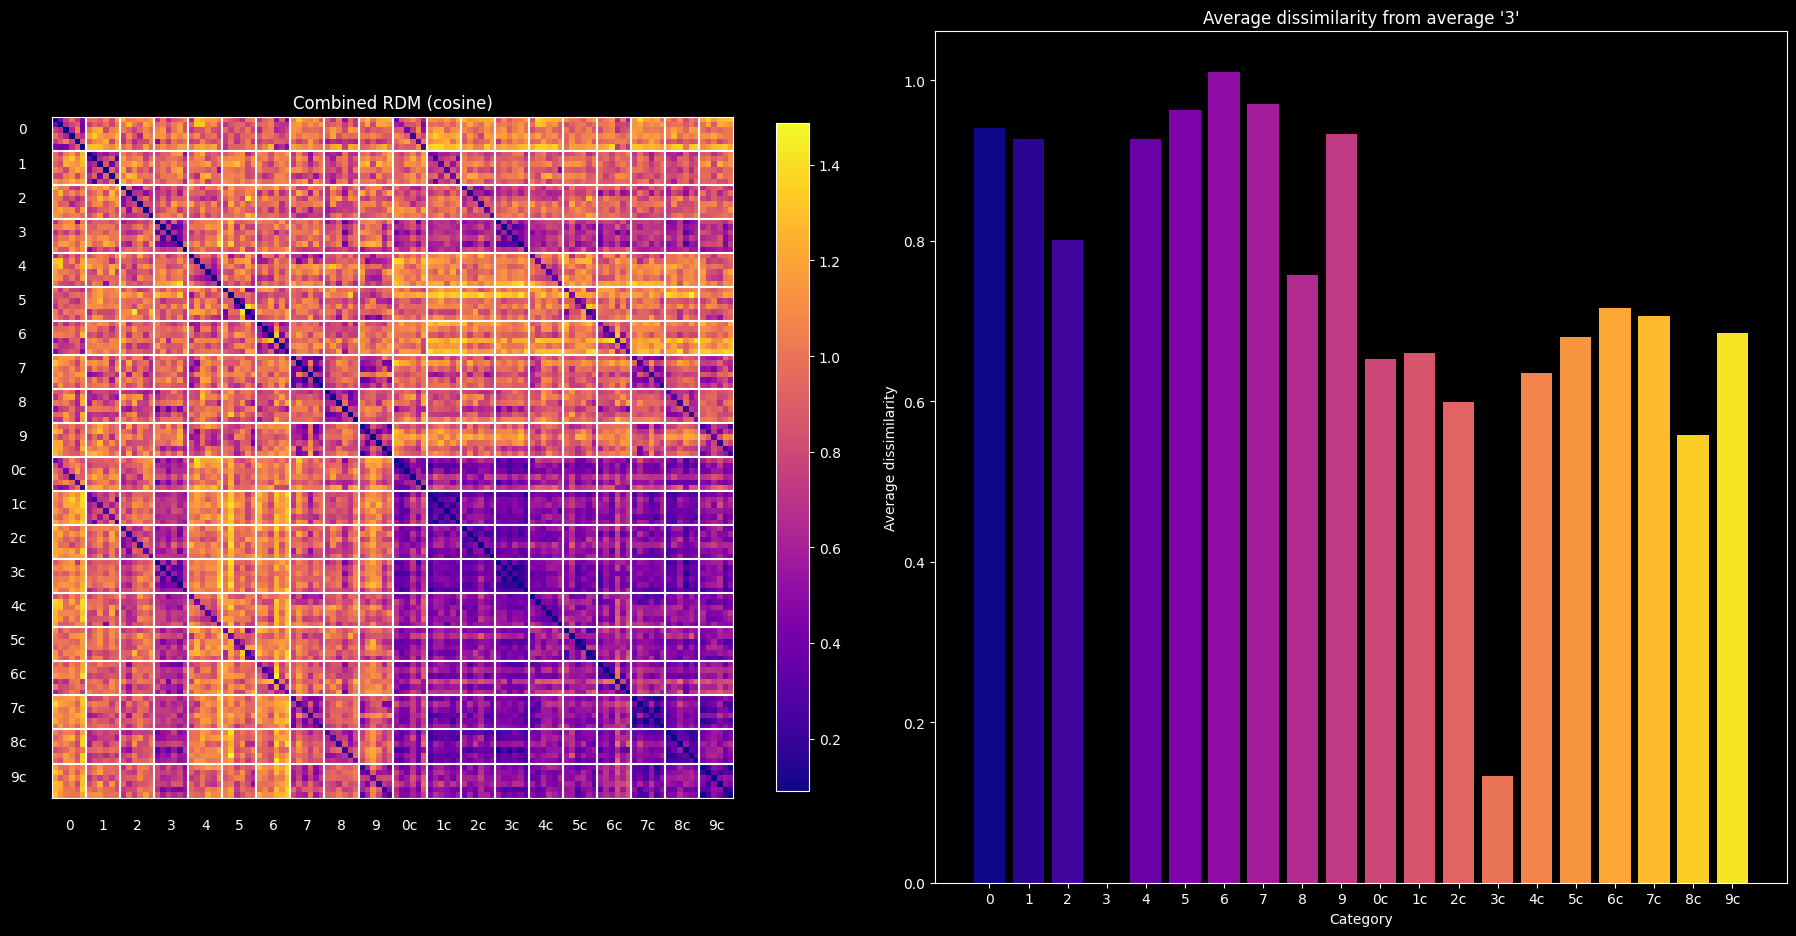

In [73]:
# ensure labels are numpy arrays for indexing
labels_test = labels_test

# RDM analysis with balanced samples per category
samples_per_class = min(len(labels_test[labels_test == i]) for i in range(10))  # Ensure we have enough samples
balanced_indices = np.concatenate([
    np.random.choice(np.where(labels_test == i)[0], samples_per_class, replace=False) for i in range(10)
])

# prepare balanced activations for the RDM
balanced_no_context = activations_no_context[balanced_indices]
balanced_with_context = activations_context[balanced_indices]
balanced_combined_activations = np.concatenate([balanced_no_context, balanced_with_context], axis=0)
balanced_combined_labels = np.concatenate([labels_test[balanced_indices], labels_test[balanced_indices] + 10])

# compute the RDM (Representational Dissimilarity Matrix) using cosine distance
rdm_combined = squareform(pdist(balanced_combined_activations, metric='cosine'))
avg_3_dissimilarities = [
    rdm_combined[balanced_combined_labels == 3, balanced_combined_labels == i].mean()
    for i in range(10)
] + [
    rdm_combined[balanced_combined_labels == 3, balanced_combined_labels == i + 10].mean()
    for i in range(10)
]

# plot the combined RDM
fig, ax = plt.subplots(1, 2, figsize=(18, 10))
ax[0].set_title("Combined RDM (cosine)")
rdm_plot = ax[0].imshow(rdm_combined, cmap='plasma', interpolation='nearest')

# adjust the colorbar size using the 'shrink' parameter
cbar = fig.colorbar(rdm_plot, ax=ax[0], shrink=0.75)  # Shrink to 75% of its original size

# set colormap limits excluding the diagonal
min_val = np.min(np.ma.masked_where(np.eye(len(balanced_combined_labels), dtype=bool), rdm_combined))
max_val = np.max(rdm_combined)
rdm_plot.set_clim(min_val, max_val)

# add separators and labels to the RDM plot
for i in range(20):  # 10 original + 10 context-modified categories
    ax[0].axhline(i * samples_per_class - 0.5, color='white', linewidth=1.5)
    ax[0].axvline(i * samples_per_class - 0.5, color='white', linewidth=1.5)
    label_text = str(i % 10) + ("c" if i >= 10 else "")
    ax[0].text(-5, i * samples_per_class + samples_per_class / 2 - 0.5, label_text, color="white", fontsize=10, ha='right')
    ax[0].text(i * samples_per_class + samples_per_class / 2 - 0.5, len(balanced_combined_labels) + 5, label_text, color="white", fontsize=10, ha='center')
ax[0].set_xticks([])
ax[0].set_yticks([])

# plot the average dissimilarity histogram from "3" (no context)
ax[1].bar(range(20), avg_3_dissimilarities, color=plt.cm.plasma(np.arange(20) / 20))
ax[1].set_xticks(range(20))
ax[1].set_xticklabels([str(i) for i in range(10)] + [f"{i}c" for i in range(10)])
ax[1].set_title("Average dissimilarity from average '3'")
ax[1].set_xlabel("Category")
ax[1].set_ylabel("Average dissimilarity")
ax[1].set_box_aspect(1)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()